# Curve Fitting & Regression
Fit linear, polynomial and exponential models to understand how each process parameter relates to Q-factor.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
CSV_PATH = 'qfactors_1.0um.csv'

## 1. Load & Aggregate

In [12]:
df = pd.read_csv(CSV_PATH)
df = df[df['q_factor'].notna() & df['q_factor'].between(0, 1)]

# Per-image aggregation
meta_cols = ['filename', 'Power(W)', 'Scanning speed(mm/s)', 'Pass', 'Range(micron)']
img = df.drop_duplicates('filename')[meta_cols].copy()
img = img.rename(columns={
    'Power(W)': 'power',
    'Scanning speed(mm/s)': 'scan_speed',
    'Pass': 'n_pass',
    'Range(micron)': 'range_um',
})

q_img = df.groupby('filename')['q_factor'].median().reset_index()
q_img.columns = ['filename', 'q_median']
img = img.merge(q_img, on='filename')

print(f'Images: {len(img)}')
print(img[['power', 'scan_speed', 'n_pass', 'range_um', 'q_median']].describe().round(3))

Images: 423
         power  scan_speed   n_pass  range_um  q_median
count  423.000     423.000  423.000   423.000   423.000
mean     1.771    1365.437    9.364    13.241     0.859
std      0.098     880.141    7.747     6.171     0.163
min      1.650      10.000    1.000     3.200     0.099
25%      1.650     600.000    5.000     8.000     0.802
50%      1.850    1250.000   10.000    13.600     0.920
75%      1.850    2050.000   15.000    16.800     0.970
max      1.850    3000.000   50.000    37.600     1.000


## 2. Model Definitions

In [13]:
def linear(x, a, b):
    return a * x + b

def poly2(x, a, b, c):
    return a * x**2 + b * x + c

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

MODELS = {
    'Linear':      linear,
    'Poly deg-2':  poly2,
    'Poly deg-3':  poly3,
    'Exponential': exponential,
}

## 3. Fitting Utility

In [14]:
def fit_models(x, y, models=MODELS):
    """
    Fit all models to (x, y) data.
    Returns a dict with fit results sorted by R².
    """
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)

    # Smart initial guesses based on data statistics
    p0_map = {
        'Linear':      [0, y.mean()],
        'Poly deg-2':  [0, 0, y.mean()],
        'Poly deg-3':  [0, 0, 0, y.mean()],
        # a * exp(b * x) + c: start with tiny b to avoid overflow
        'Exponential': [y.std(), 1e-4 * np.sign(np.corrcoef(x, y)[0, 1]), y.mean()],
    }

    results = {}
    for name, fn in models.items():
        try:
            popt, _ = curve_fit(fn, x, y, p0=p0_map[name], maxfev=10000)
            y_pred = fn(x, *popt)
            r2   = r2_score(y, y_pred)
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            results[name] = {'params': popt, 'r2': r2, 'rmse': rmse, 'fn': fn}
        except Exception:
            results[name] = {'params': None, 'r2': np.nan, 'rmse': np.nan, 'fn': fn}

    return dict(sorted(results.items(), key=lambda x: x[1]['r2'], reverse=True))


def plot_fits(x, y, results, xlabel, title, top_n=3):
    """Scatter plot with top_n best fits overlaid."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(x, y, alpha=0.5, s=25, color='steelblue', label='Data', zorder=3)

    x_line = np.linspace(x.min(), x.max(), 300)
    colors = ['red', 'orange', 'green', 'purple']

    for i, (name, res) in enumerate(list(results.items())[:top_n]):
        if res['params'] is not None:
            y_line = res['fn'](x_line, *res['params'])
            ax.plot(x_line, y_line, color=colors[i], linewidth=2,
                    label=f"{name}  R²={res['r2']:.3f}  RMSE={res['rmse']:.3f}")

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median Q-Factor')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_summary(results):
    print(f"{'Model':<15} {'R²':>8} {'RMSE':>8}")
    print('-' * 33)
    for name, res in results.items():
        r2   = f"{res['r2']:.4f}"   if not np.isnan(res['r2'])   else '  failed'
        rmse = f"{res['rmse']:.4f}" if not np.isnan(res['rmse']) else '  failed'
        print(f"{name:<15} {r2:>8} {rmse:>8}")

## 4. Q vs Scan Speed

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.1626   0.1487
Poly deg-2        0.1338   0.1513
Linear            0.1016   0.1540
Exponential       0.1016   0.1540


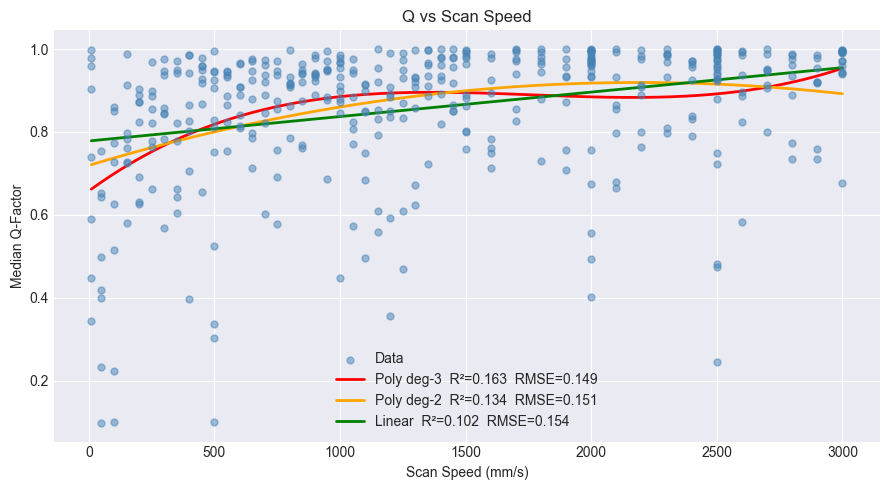

In [15]:
x, y = img['scan_speed'], img['q_median']
results_speed = fit_models(x, y)
print_summary(results_speed)
plot_fits(x, y, results_speed, xlabel='Scan Speed (mm/s)', title='Q vs Scan Speed')

## 5. Q vs Number of Passes

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.0832   0.1556
Poly deg-2        0.0824   0.1557
Linear            0.0773   0.1561
Exponential       0.0773   0.1561


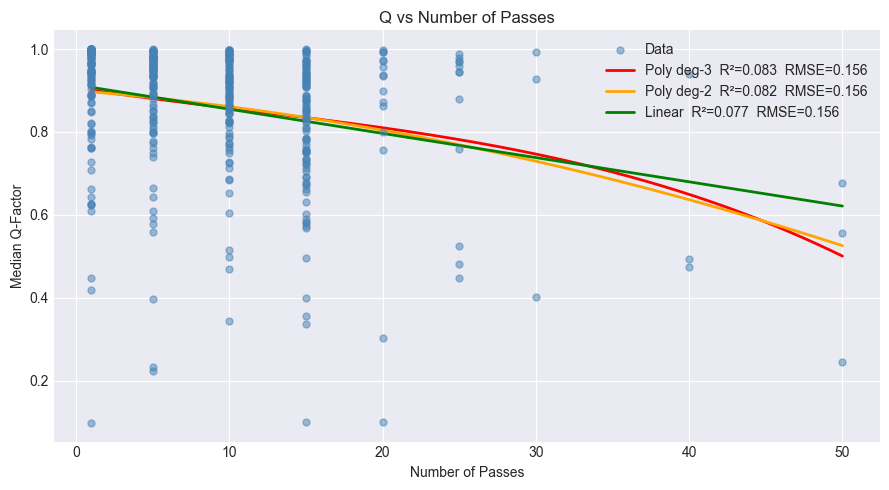

In [16]:
x, y = img['n_pass'], img['q_median']
results_pass = fit_models(x, y)
print_summary(results_pass)
plot_fits(x, y, results_pass, xlabel='Number of Passes', title='Q vs Number of Passes')

## 6. Q vs Range

Model                 R²     RMSE
---------------------------------
Poly deg-3        0.0664   0.1570
Poly deg-2        0.0664   0.1570
Exponential       0.0622   0.1574
Linear            0.0448   0.1588


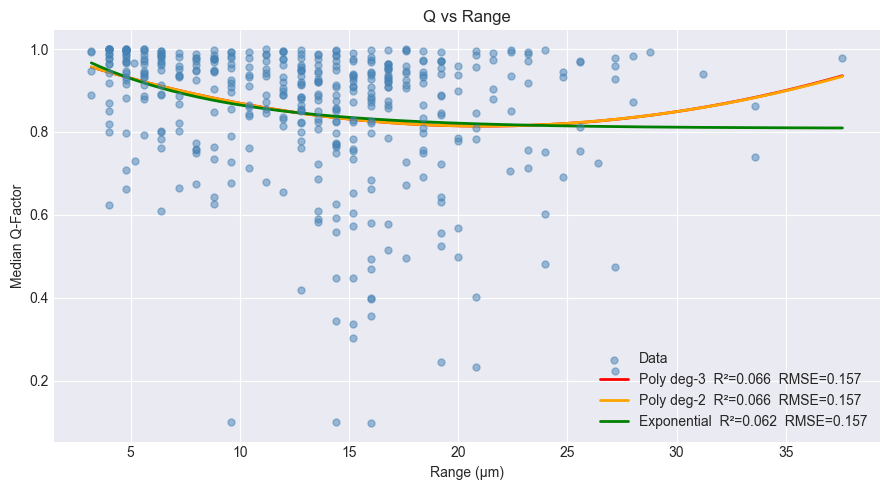

In [17]:
x, y = img['range_um'], img['q_median']
results_range = fit_models(x, y)
print_summary(results_range)
plot_fits(x, y, results_range, xlabel='Range (µm)', title='Q vs Range')

## 7. Q vs Power

Model                 R²     RMSE
---------------------------------
Linear            0.0118   0.1616
Poly deg-2        0.0118   0.1616
Poly deg-3        0.0118   0.1616
Exponential       0.0118   0.1616


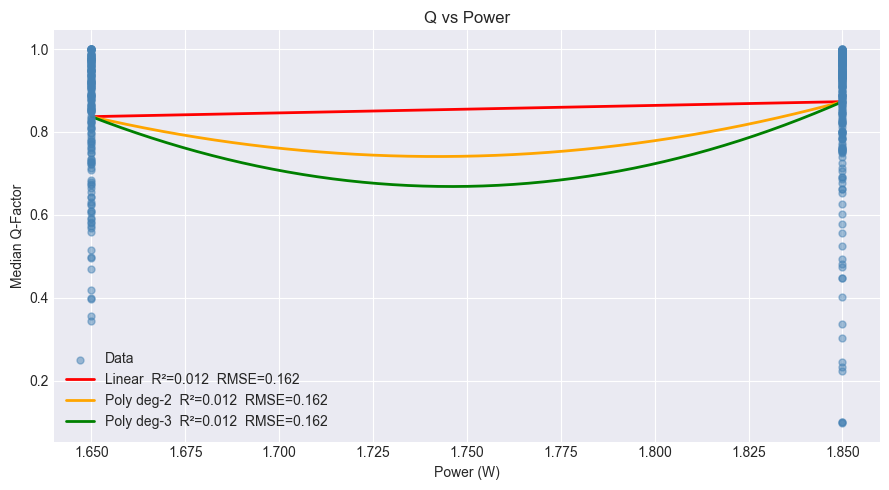

In [18]:
x, y = img['power'], img['q_median']
results_power = fit_models(x, y)
print_summary(results_power)
plot_fits(x, y, results_power, xlabel='Power (W)', title='Q vs Power')

## 8. Summary

In [19]:
all_results = {
    'scan_speed': results_speed,
    'n_pass':     results_pass,
    'range_um':   results_range,
    'power':      results_power,
}

rows = []
for param, res in all_results.items():
    best_name = list(res.keys())[0]
    best = res[best_name]
    rows.append({
        'parameter':  param,
        'best_model': best_name,
        'R²':         round(best['r2'], 4),
        'RMSE':       round(best['rmse'], 4),
    })

summary = pd.DataFrame(rows).sort_values('R²', ascending=False)
print('Best model per parameter (ranked by R²):')
print(summary.to_string(index=False))

Best model per parameter (ranked by R²):
 parameter best_model     R²   RMSE
scan_speed Poly deg-3 0.1626 0.1487
    n_pass Poly deg-3 0.0832 0.1556
  range_um Poly deg-3 0.0664 0.1570
     power     Linear 0.0118 0.1616


## 9. Multi-Parameter Regression
Combine all process parameters into a single model to capture combined and interaction effects.

In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

FEATURES = ['scan_speed', 'n_pass', 'range_um', 'power']
X = img[FEATURES].values
y = img['q_median'].values

# --- Multi-linear (all 4 features, no interactions) ---
lr = LinearRegression()
cv_r2_lr = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()
lr.fit(X, y)
y_pred_lr = lr.predict(X)
r2_lr   = r2_score(y, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y, y_pred_lr))

# Standardized coefficients for interpretability
x_std    = (X - X.mean(0)) / X.std(0)
lr_std   = LinearRegression().fit(x_std, y)

print('Multi-linear (all 4 features)')
print(f'  Train R²: {r2_lr:.4f}   RMSE: {rmse_lr:.4f}')
print(f'  CV R²:    {cv_r2_lr:.4f}')
print()
print('  Standardized coefficients (larger |value| = stronger effect):')
for feat, coef in zip(FEATURES, lr_std.coef_):
    print(f'    {feat:<12}: {coef:+.4f}')


Multi-linear (all 4 features)
  Train R²: 0.2364   RMSE: 0.1420
  CV R²:    0.0407

  Standardized coefficients (larger |value| = stronger effect):
    scan_speed  : +0.0630
    n_pass      : -0.0690
    range_um    : +0.0140
    power       : +0.0195


In [21]:
# --- Poly deg-2 with all pairwise interactions + Ridge ---
# Ridge regularisation handles n_pass <-> range_um collinearity (r=0.66)
model_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0),
)
cv_r2_poly = cross_val_score(model_poly, X, y, cv=5, scoring='r2').mean()
model_poly.fit(X, y)
y_pred_poly = model_poly.predict(X)
r2_poly   = r2_score(y, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print('Poly deg-2 + Ridge (all interactions)')
print(f'  Train R²: {r2_poly:.4f}   RMSE: {rmse_poly:.4f}')
print(f'  CV R²:    {cv_r2_poly:.4f}')

poly_step  = model_poly.named_steps['polynomialfeatures']
ridge_step = model_poly.named_steps['ridge']
feat_names = poly_step.get_feature_names_out(FEATURES)
top_idx    = np.argsort(np.abs(ridge_step.coef_))[::-1][:8]
print()
print('  Top 8 terms by |coefficient|:')
for i in top_idx:
    print(f'    {feat_names[i]:<25}: {ridge_step.coef_[i]:+.4f}')


Poly deg-2 + Ridge (all interactions)
  Train R²: 0.3189   RMSE: 0.1341
  CV R²:    0.1280

  Top 8 terms by |coefficient|:
    scan_speed power         : +0.1808
    scan_speed^2             : -0.0968
    n_pass                   : -0.0733
    scan_speed               : -0.0682
    n_pass^2                 : -0.0624
    scan_speed range_um      : +0.0510
    range_um                 : -0.0443
    range_um^2               : +0.0413


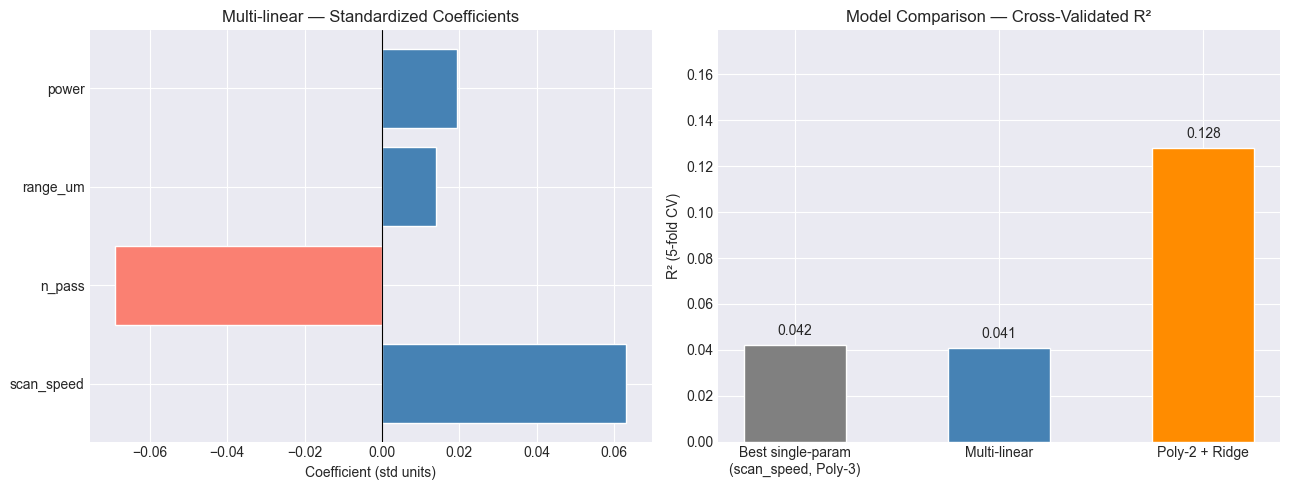

In [22]:
# CV reference: best single-param model (scan_speed, Poly deg-3)
pipe_speed   = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
cv_r2_speed  = cross_val_score(pipe_speed, img[['scan_speed']].values, y, cv=5, scoring='r2').mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: standardized coefficients
bar_colors = ['steelblue' if c > 0 else 'salmon' for c in lr_std.coef_]
axes[0].barh(FEATURES, lr_std.coef_, color=bar_colors)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_title('Multi-linear — Standardized Coefficients')
axes[0].set_xlabel('Coefficient (std units)')

# Right: CV R² comparison
labels   = ['Best single-param\n(scan_speed, Poly-3)', 'Multi-linear', 'Poly-2 + Ridge']
cv_r2s   = [cv_r2_speed, cv_r2_lr, cv_r2_poly]
clrs     = ['gray', 'steelblue', 'darkorange']
bars     = axes[1].bar(labels, cv_r2s, color=clrs, width=0.5)
axes[1].set_ylabel('R² (5-fold CV)')
axes[1].set_title('Model Comparison — Cross-Validated R²')
axes[1].set_ylim(0, max(max(cv_r2s) * 1.4, 0.1))
for bar, val in zip(bars, cv_r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
